In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore")

# Load cleaned data
df = pd.read_csv("tmdb_cleaned_with_eda.csv")

# Fill NaN just in case
df["tags"] = df["tags"].fillna("").astype(str)
df["title"] = df["title"].astype(str)
df["genres"] = df["genres"].fillna("").astype(str)
df["original_language"] = df["original_language"].fillna("").astype(str)

df = df.reset_index(drop=True)
print("Dataset shape:", df.shape)

Dataset shape: (409891, 19)


## Model 1 for POPULARITY-BASED RECOMMENDER

In [4]:


C = df["vote_average"].mean()       # mean rating across all movies
m = df["vote_count"].quantile(0.80) # minimum votes required (80th percentile)

print(f"Mean rating (C): {C:.2f}")
print(f"Minimum votes threshold (m): {m:.0f}")

def weighted_rating(x, m=m, C=C):
    v = x["vote_count"]
    R = x["vote_average"]
    return (v / (v + m)) * R + (m / (v + m)) * C

# Apply to all movies
df["weighted_score"] = df.apply(weighted_rating, axis=1)

def recommend_popular(genre=None, language=None, n=10):
    """
    Recommend top N movies by weighted score.
    Optionally filter by genre and/or language.
    """
    filtered = df.copy()
    
    if genre:
        filtered = filtered[
            filtered["genres"].str.contains(genre, case=False, na=False)
        ]
    if language:
        filtered = filtered[
            filtered["original_language"] == language
        ]
    
    result = filtered.sort_values("weighted_score", ascending=False).head(n)
    return result[["title", "release_year", "genres", "vote_average", "vote_count", "weighted_score"]]

# Test it
print("\n── Top 10 Overall ──")
display(recommend_popular())

print("\n── Top 10 Action Movies ──")
display(recommend_popular(genre="Action"))

print("\n── Top 10 English Drama Movies ──")
display(recommend_popular(genre="Drama", language="en"))

Mean rating (C): 3.39
Minimum votes threshold (m): 10

── Top 10 Overall ──


,title,release_year,genres,vote_average,vote_count,weighted_score
312552,The Way to the Heart,2024.0,"Drama, Comedy",9.900,143.0,9.474642
196345,Nude,2017.0,Documentary,9.400,165.0,9.056687
250802,BTS World Tour: Love Yourself - Japan Edition,2019.0,"Music, Documentary",9.203,327.0,9.030567
171400,What's New Scooby-Doo? Vol. 3: Halloween Boos ...,2004.0,"Animation, Comedy, Family, Mystery",9.900,52.0,8.850326
200045,What's New Scooby-Doo? Vol. 4: Merry Scary Hol...,2004.0,"Animation, Comedy, Science Fiction, Action, Fa...",10.000,46.0,8.820003
181255,What's New Scooby-Doo? Vol. 10: Monstrous Tails,2006.0,"Animation, Comedy, Mystery",9.800,54.0,8.798753
163240,"What's New, Scooby-Doo? Vol. 1: Space Ape at t...",2003.0,"Animation, Comedy, Family, Mystery",9.900,48.0,8.777934
163244,"What's New, Scooby-Doo? Vol. 5: Sports Spookta...",2005.0,"Family, Animation, Comedy, Adventure, Mystery",9.900,48.0,8.777934
265333,Break the Silence: The Movie,2020.0,"Music, Documentary",9.049,184.0,8.757403
160763,"What's New, Scooby-Doo? Vol. 7: Ghosts on the Go!",2006.0,"Animation, Comedy, Family, Mystery",9.800,50.0,8.732003



── Top 10 Action Movies ──


,title,release_year,genres,vote_average,vote_count,weighted_score
200045,What's New Scooby-Doo? Vol. 4: Merry Scary Hol...,2004.0,"Animation, Comedy, Science Fiction, Action, Fa...",10.000,46.0,8.820003
111,The Dark Knight,2008.0,"Action, Crime, Thriller",8.528,35562.0,8.526556
83,The Lord of the Rings: The Return of the King,2003.0,"Adventure, Fantasy, Action",8.496,26368.0,8.494065
281,Seven Samurai,1954.0,"Action, Drama",8.500,4175.0,8.487795
81,The Lord of the Rings: The Fellowship of the Ring,2001.0,"Adventure, Fantasy, Action",8.432,27373.0,8.430159
369330,Attack on Titan: THE LAST ATTACK,2024.0,"Animation, Action, Adventure, Drama",8.700,181.0,8.422095
82,The Lord of the Rings: The Two Towers,2002.0,"Adventure, Fantasy, Action",8.415,23737.0,8.412885
8097,Harakiri,1962.0,"Action, Drama, History",8.433,1189.0,8.390957
137310,Spider-Man: Into the Spider-Verse,2018.0,"Animation, Action, Adventure, Science Fiction",8.393,17103.0,8.390078
1230,The Empire Strikes Back,1980.0,"Adventure, Action, Science Fiction",8.392,18293.0,8.389268



── Top 10 English Drama Movies ──


,title,release_year,genres,vote_average,vote_count,weighted_score
312552,The Way to the Heart,2024.0,"Drama, Comedy",9.900,143.0,9.474642
222,The Shawshank Redemption,1994.0,"Drama, Crime",8.719,30185.0,8.717236
185,The Godfather,1972.0,"Drama, Crime",8.686,22792.0,8.683678
297,12 Angry Men,1957.0,Drama,8.600,9909.0,8.594749
187,The Godfather Part II,1974.0,"Drama, Crime",8.571,13800.0,8.567250
324,Schindler's List,1993.0,"Drama, History, War",8.567,17354.0,8.564020
378,The Green Mile,1999.0,"Fantasy, Drama, Crime",8.504,19128.0,8.501329
7,Forrest Gump,1994.0,"Comedy, Drama, Romance",8.500,29588.0,8.498274
77500,Interstellar,2014.0,"Adventure, Drama, Science Fiction",8.470,39483.0,8.468714
595,GoodFellas,1990.0,"Drama, Crime",8.453,14237.0,8.449448


## Model 2 Recomendation by similarity

In [7]:
# ── 2. TF-IDF VECTORIZATION ───────────────────────────────────────────────────
print("Fitting TF-IDF...")

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=30000,
    ngram_range=(1, 2),
    sublinear_tf=True      # dampens high frequency terms → better quality
)

tfidf_matrix = tfidf.fit_transform(df["tags"])
print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Memory (sparse):", tfidf_matrix.data.nbytes / 1e6, "MB")

Fitting TF-IDF...
TF-IDF matrix shape: (409891, 30000)
Memory (sparse): 150.541632 MB


In [9]:
from sklearn.neighbors import NearestNeighbors

# ── 3. FIT NEARESTNEIGHBORS ───────────────────────────────────────────────────
print("Fitting NearestNeighbors model...")

nn_model = NearestNeighbors(
    metric="cosine",
    algorithm="brute",   # best for sparse high-dimensional data
    n_neighbors=11,      # 10 recommendations + 1 (self)
    n_jobs=-1            # use all CPU cores
)

nn_model.fit(tfidf_matrix)
print("Model fitted successfully.")

Fitting NearestNeighbors model...
Model fitted successfully.


In [11]:
# ── 4. TITLE → INDEX MAPPING ──────────────────────────────────────────────────
title_to_idx = defaultdict(list)
for idx, title in enumerate(df["title"]):
    title_to_idx[title.lower().strip()].append(idx)

def get_movie_idx(title):
    """
    Returns movie index. If multiple movies share same title,
    returns the one with the highest vote_count (most popular version).
    """
    matches = title_to_idx.get(title.lower().strip(), [])
    if not matches:
        return None
    if len(matches) == 1:
        return matches[0]
    # Pick the one with highest vote_count among duplicates
    best = max(matches, key=lambda i: df.loc[i, "vote_count"]
               if pd.notna(df.loc[i, "vote_count"]) else 0)
    return best

In [13]:
# ── 5. RECOMMEND FUNCTION ─────────────────────────────────────────────────────
def recommend_nn(title, n=10, same_genre=False, year_range=None, min_votes=0):
    """
    Recommend movies similar to the given title.
    
    Parameters:
        title      : movie title (string)
        n          : number of recommendations to return
        same_genre : if True, only return movies sharing at least 1 genre
        year_range : tuple (min_year, max_year), e.g. (2000, 2023)
        min_votes  : minimum vote_count threshold
    """
    idx = get_movie_idx(title)
    
    if idx is None:
        print(f"Movie '{title}' not found in database.")
        return pd.DataFrame()
    
    query_title    = df.loc[idx, "title"]
    query_year     = df.loc[idx, "release_year"]
    query_genres   = set(df.loc[idx, "genres"].lower().replace(", ", ",").split(","))
    query_genres   = {g.strip() for g in query_genres if g.strip()}
    
    print(f"Finding recommendations for: '{query_title}' ({int(query_year) if pd.notna(query_year) else 'N/A'})")
    
    # Fetch more candidates to allow for filtering
    n_candidates = min(n * 10, len(df) - 1)
    query_vector = tfidf_matrix[idx]
    
    start = time.time()
    distances, indices = nn_model.kneighbors(
        query_vector,
        n_neighbors=n_candidates + 1
    )
    elapsed = time.time() - start
    
    sim_scores = (1 - distances.flatten())
    indices    = indices.flatten()
    
    results = []
    for i, s in zip(indices, sim_scores):
        if i == idx:   # skip self
            continue
        if len(results) >= n:
            break
        
        row = df.loc[i]
        
        # Filter: minimum votes
        if min_votes and pd.notna(row["vote_count"]):
            if row["vote_count"] < min_votes:
                continue
        
        # Filter: same genre
        if same_genre:
            rec_genres = set(str(row["genres"]).lower().replace(", ", ",").split(","))
            rec_genres = {g.strip() for g in rec_genres if g.strip()}
            if not query_genres.intersection(rec_genres):
                continue
        
        # Filter: year range
        if year_range and pd.notna(row["release_year"]):
            if not (year_range[0] <= row["release_year"] <= year_range[1]):
                continue
        
        results.append({
            "title":            row["title"],
            "release_year":     int(row["release_year"]) if pd.notna(row["release_year"]) else None,
            "genres":           row["genres"],
            "vote_average":     round(row["vote_average"], 1) if pd.notna(row["vote_average"]) else None,
            "vote_count":       int(row["vote_count"]) if pd.notna(row["vote_count"]) else None,
            "similarity_score": round(s, 4)
        })
    
    result_df = pd.DataFrame(results)
    print(f"Query time: {elapsed:.3f}s | Results: {len(result_df)}")
    return result_df

In [15]:
# ── 6. TEST ALL VARIATIONS ────────────────────────────────────────────────────
import time 


print("=" * 60)
print("TEST 1 — Basic recommendation")
display(recommend_nn("The Dark Knight", n=10))

print("=" * 60)
print("TEST 2 — Same genre only")
display(recommend_nn("Inception", n=10, same_genre=True))

print("=" * 60)
print("TEST 3 — Year range filter (2000–2023)")
display(recommend_nn("The Dark Knight", n=10, year_range=(2000, 2023)))

print("=" * 60)
print("TEST 4 — Same genre + minimum 500 votes")
display(recommend_nn("Toy Story", n=10, same_genre=True, min_votes=500))

print("=" * 60)
print("TEST 5 — Movie not in dataset")
recommend_nn("This Movie Does Not Exist")

TEST 1 — Basic recommendation
Finding recommendations for: 'The Dark Knight' (2008)
Query time: 0.356s | Results: 10


,title,release_year,genres,vote_average,vote_count,similarity_score
0,The Dark Knight Rises,2012,"Action, Crime, Drama, Thriller",7.8,24220,0.2295
1,Batman Begins,2005,"Drama, Crime, Action",7.7,22478,0.1996
2,Ending the Knight,2012,Documentary,7.2,33,0.1892
3,Batman Forever,1995,"Action, Crime, Fantasy",5.5,5551,0.1775
4,Law Abiding Citizen,2009,"Drama, Crime, Thriller",7.4,5625,0.1591
5,The Current War,2018,"Drama, History",6.7,1131,0.1567
6,The Ten,2007,Comedy,4.8,208,0.1527
7,Batman,1989,"Fantasy, Action, Crime",7.2,8513,0.1520
8,Saints and Soldiers,2003,"War, Drama, Action, Adventure, History",6.3,301,0.1474
9,Outlaw Johnny Black,2023,"Action, Comedy, Western",5.4,35,0.1468


TEST 2 — Same genre only
Finding recommendations for: 'Inception' (2010)
Query time: 0.187s | Results: 10


,title,release_year,genres,vote_average,vote_count,similarity_score
0,Dunkirk,2017,"War, Action, Drama",7.5,17457,0.1609
1,The Dark Knight Rises,2012,"Action, Crime, Drama, Thriller",7.8,24220,0.1468
2,Interstellar,2014,"Adventure, Drama, Science Fiction",8.5,39483,0.1427
3,Tenet,2020,"Action, Thriller, Science Fiction",7.2,11022,0.1390
4,Batman Begins,2005,"Drama, Crime, Action",7.7,22478,0.1384
5,The Prestige,2006,"Drama, Mystery, Science Fiction",8.2,17459,0.1225
6,Journey 2: The Mysterious Island,2012,"Adventure, Action, Science Fiction",6.1,4481,0.1195
7,Dreamality,2025,"Comedy, Science Fiction",9.0,1,0.1126
8,Charles Beaumont: The Short Life of Twilight Z...,2010,"Documentary, Fantasy, Science Fiction",2.0,1,0.1115
9,Twist,2021,"Crime, Drama, Action",5.8,192,0.1103


TEST 3 — Year range filter (2000–2023)
Finding recommendations for: 'The Dark Knight' (2008)
Query time: 0.158s | Results: 10


,title,release_year,genres,vote_average,vote_count,similarity_score
0,The Dark Knight Rises,2012,"Action, Crime, Drama, Thriller",7.8,24220,0.2295
1,Batman Begins,2005,"Drama, Crime, Action",7.7,22478,0.1996
2,Ending the Knight,2012,Documentary,7.2,33,0.1892
3,Law Abiding Citizen,2009,"Drama, Crime, Thriller",7.4,5625,0.1591
4,The Current War,2018,"Drama, History",6.7,1131,0.1567
5,The Ten,2007,Comedy,4.8,208,0.1527
6,Saints and Soldiers,2003,"War, Drama, Action, Adventure, History",6.3,301,0.1474
7,Outlaw Johnny Black,2023,"Action, Comedy, Western",5.4,35,0.1468
8,Rogue One: A Star Wars Story,2016,"Action, Adventure, Science Fiction",7.5,16282,0.1451
9,Contagion,2011,"Drama, Thriller, Science Fiction",6.6,6495,0.1421


TEST 4 — Same genre + minimum 500 votes
Finding recommendations for: 'Toy Story' (1995)
Query time: 0.161s | Results: 10


,title,release_year,genres,vote_average,vote_count,similarity_score
0,Toy Story 2,1999,"Animation, Comedy, Family",7.6,14796,0.4500
1,Toy Story 3,2010,"Animation, Family, Comedy",7.8,15626,0.3720
2,Toy Story 4,2019,"Family, Comedy, Animation, Adventure",7.5,10448,0.2685
3,A Bug's Life,1998,"Family, Animation, Adventure, Comedy",7.0,9671,0.2059
4,Treasure Planet,2002,"Science Fiction, Adventure, Animation, Family,...",7.6,4553,0.1868
5,"Monsters, Inc.",2001,"Animation, Comedy, Family",7.8,19646,0.1859
6,Finding Nemo,2003,"Animation, Family, Adventure",7.8,20451,0.1686
7,Cars,2006,"Animation, Adventure, Comedy, Family",7.0,15010,0.1660
8,The Emperor's New Groove,2000,"Adventure, Animation, Comedy, Family, Fantasy",7.6,7247,0.1644
9,Aladdin,1992,"Animation, Family, Adventure, Fantasy, Romance",7.7,11957,0.1625


TEST 5 — Movie not in dataset
Movie 'This Movie Does Not Exist' not found in database.


""


In [17]:
# ── 7. QUICK EVALUATION ───────────────────────────────────────────────────────

def evaluate_genre_overlap(model_func, sample_size=200, n=10, **kwargs):
    """
    For a random sample of movies, compute the % of recommendations
    that share at least 1 genre with the query movie.
    Higher = better genre relevance.
    """
    rng = np.random.default_rng(42)
    sample_indices = rng.choice(len(df), size=sample_size, replace=False)
    
    scores = []
    for idx in sample_indices:
        title      = df.loc[idx, "title"]
        q_genres   = set(df.loc[idx, "genres"].lower().split(","))
        q_genres   = {g.strip() for g in q_genres if g.strip()}
        
        recs = model_func(title, n=n, **kwargs)
        if recs.empty:
            continue
        
        matches = 0
        for _, row in recs.iterrows():
            rec_genres = set(str(row["genres"]).lower().split(","))
            rec_genres = {g.strip() for g in rec_genres if g.strip()}
            if q_genres.intersection(rec_genres):
                matches += 1
        
        scores.append(matches / len(recs))
    
    return np.mean(scores) if scores else 0.0

print("Evaluating Model 2 (NearestNeighbors, no filter)...")
score_basic = evaluate_genre_overlap(recommend_nn, sample_size=200)

print("Evaluating Model 2 (NearestNeighbors, same_genre=True)...")
score_filtered = evaluate_genre_overlap(recommend_nn, sample_size=200, same_genre=True)

print(f"\nGenre Overlap — No filter:      {score_basic:.4f}")
print(f"Genre Overlap — Genre filtered: {score_filtered:.4f}")

Evaluating Model 2 (NearestNeighbors, no filter)...
Finding recommendations for: 'The Big Hit' (1998)
Query time: 0.215s | Results: 10
Finding recommendations for: 'Shadow of the Eagle' (2005)
Query time: 0.143s | Results: 10
Finding recommendations for: 'Charged: The Eduardo Garcia Story' (2017)
Query time: 0.162s | Results: 10
Finding recommendations for: 'Moro no Brasil' (2002)
Query time: 0.156s | Results: 10
Finding recommendations for: 'Olsen Gang Gets Polished' (2010)
Query time: 0.153s | Results: 10
Finding recommendations for: 'Made in USSR' (1991)
Query time: 0.140s | Results: 10
Finding recommendations for: 'Loving Carolina' (2018)
Query time: 0.160s | Results: 10
Finding recommendations for: 'All About "All About Lily Chou-Chou"' (2002)
Query time: 0.157s | Results: 10
Finding recommendations for: 'Biohazard: The Alien Force' (1994)
Query time: 0.152s | Results: 10
Finding recommendations for: 'Maneater' (2022)
Query time: 0.145s | Results: 10
Finding recommendations for: '

In [19]:
# ── 8. SUMMARY ────────────────────────────────────────────────────────────────

summary = pd.DataFrame({
    "Model":   ["Model 2A — NearestNeighbors (no filter)",
                "Model 2B — NearestNeighbors (genre filter)"],
    "Vectorizer":        ["TF-IDF (unigrams + bigrams)", "TF-IDF (unigrams + bigrams)"],
    "Filter":            ["None", "Same genre"],
    "Genre Overlap":     [f"{score_basic:.4f}", f"{score_filtered:.4f}"],
})

display(summary)

,Model,Vectorizer,Filter,Genre Overlap
0,Model 2A — NearestNeighbors (no filter),TF-IDF (unigrams + bigrams),None,0.5005
1,Model 2B — NearestNeighbors (genre filter),TF-IDF (unigrams + bigrams),Same genre,0.9046


## MODEL 3: WEIGHTED HYBRID RECOMMENDER 

In [22]:
# Combines Model 1 (popularity/weighted rating) + Model 2 (TF-IDF similarity)
# final_score = α × similarity_score + (1 - α) × normalized_weighted_rating
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns


In [24]:
# ── 1. NORMALIZE WEIGHTED SCORE FROM MODEL 1 ─────────────────────────────────
# We need weighted_score on same scale as similarity (0 to 1)

scaler = MinMaxScaler()
df["weighted_score_norm"] = scaler.fit_transform(
    df[["weighted_score"]]
)

print("Weighted score normalized:")
print(df["weighted_score_norm"].describe())

Weighted score normalized:
count    409891.000000
mean          0.287922
std           0.121463
min           0.000000
25%           0.209253
50%           0.228257
75%           0.324693
max           1.000000
Name: weighted_score_norm, dtype: float64


In [26]:
# ── 2. HYBRID RECOMMEND FUNCTION ─────────────────────────────────────────────

def recommend_hybrid(title, n=10, alpha=0.5,
                     same_genre=False, year_range=None, min_votes=0):
    """
    Hybrid recommender combining content similarity and popularity.

    final_score = alpha × similarity + (1 - alpha) × normalized_weighted_rating

    Parameters:
        title      : movie title (string)
        n          : number of recommendations
        alpha      : weight for similarity score (0 = pure popularity, 
                                                  1 = pure similarity)
        same_genre : only return movies sharing at least 1 genre
        year_range : tuple (min_year, max_year) e.g. (2000, 2023)
        min_votes  : minimum vote_count threshold
    """
    idx = get_movie_idx(title)

    if idx is None:
        print(f"Movie '{title}' not found in database.")
        return pd.DataFrame()

    query_title  = df.loc[idx, "title"]
    query_year   = df.loc[idx, "release_year"]
    query_genres = set(df.loc[idx, "genres"].lower().replace(", ", ",").split(","))
    query_genres = {g.strip() for g in query_genres if g.strip()}

    print(f"Finding hybrid recommendations for: '{query_title}' "
          f"({int(query_year) if pd.notna(query_year) else 'N/A'}) | alpha={alpha}")

    # Fetch candidates using TF-IDF NearestNeighbors (from Model 2)
    n_candidates = min(n * 20, len(df) - 1)
    query_vector = tfidf_matrix[idx]

    start = time.time()
    distances, indices = nn_model.kneighbors(
        query_vector,
        n_neighbors=n_candidates + 1
    )
    elapsed = time.time() - start

    sim_scores = (1 - distances.flatten())
    indices    = indices.flatten()

    results = []
    for i, s in zip(indices, sim_scores):
        if i == idx:
            continue

        row = df.loc[i]

        # Filter: minimum votes
        if min_votes and pd.notna(row["vote_count"]):
            if row["vote_count"] < min_votes:
                continue

        # Filter: same genre
        if same_genre:
            rec_genres = set(str(row["genres"]).lower().replace(", ", ",").split(","))
            rec_genres = {g.strip() for g in rec_genres if g.strip()}
            if not query_genres.intersection(rec_genres):
                continue

        # Filter: year range
        if year_range and pd.notna(row["release_year"]):
            if not (year_range[0] <= row["release_year"] <= year_range[1]):
                continue

        # ── HYBRID SCORE ──────────────────────────────────────────────────────
        pop_score = row["weighted_score_norm"] if pd.notna(row["weighted_score_norm"]) else 0.0
        hybrid_score = alpha * s + (1 - alpha) * pop_score

        results.append({
            "title":              row["title"],
            "release_year":       int(row["release_year"]) if pd.notna(row["release_year"]) else None,
            "genres":             row["genres"],
            "vote_average":       round(row["vote_average"], 1) if pd.notna(row["vote_average"]) else None,
            "vote_count":         int(row["vote_count"]) if pd.notna(row["vote_count"]) else None,
            "similarity_score":   round(s, 4),
            "popularity_score":   round(float(pop_score), 4),
            "hybrid_score":       round(hybrid_score, 4)
        })

    # Sort by hybrid score
    result_df = pd.DataFrame(results)
    result_df  = result_df.sort_values("hybrid_score", ascending=False).head(n)

    print(f"Query time: {elapsed:.3f}s | Results: {len(result_df)}")
    return result_df

In [28]:
# ── 3. TEST MODEL 3 ───────────────────────────────────────────────────────────

print("=" * 60)
print("TEST 1 — Balanced hybrid (alpha=0.5)")
display(recommend_hybrid("The Dark Knight", n=10, alpha=0.5))

print("=" * 60)
print("TEST 2 — More similarity focused (alpha=0.7)")
display(recommend_hybrid("Inception", n=10, alpha=0.7))

print("=" * 60)
print("TEST 3 — More popularity focused (alpha=0.3)")
display(recommend_hybrid("Inception", n=10, alpha=0.3))

print("=" * 60)
print("TEST 4 — Same genre + min 500 votes")
display(recommend_hybrid("Toy Story", n=10, alpha=0.5,
                          same_genre=True, min_votes=500))

TEST 1 — Balanced hybrid (alpha=0.5)
Finding hybrid recommendations for: 'The Dark Knight' (2008) | alpha=0.5
Query time: 0.251s | Results: 10


,title,release_year,genres,vote_average,vote_count,similarity_score,popularity_score,hybrid_score
182,The Shawshank Redemption,1994,"Drama, Crime",8.7,30185,0.1160,0.9015,0.5088
0,The Dark Knight Rises,2012,"Action, Crime, Drama, Thriller",7.8,24220,0.2295,0.7811,0.5053
1,Batman Begins,2005,"Drama, Crime, Action",7.7,22478,0.1996,0.7720,0.4858
51,Saving Private Ryan,1998,"War, Drama, History",8.2,17068,0.1286,0.8339,0.4813
72,The Prestige,2006,"Drama, Mystery, Science Fiction",8.2,17459,0.1248,0.8347,0.4798
54,The Departed,2006,"Drama, Thriller, Crime",8.2,16087,0.1277,0.8287,0.4782
189,Avengers: Endgame,2019,"Adventure, Science Fiction, Action",8.2,27561,0.1155,0.8385,0.4770
15,Bohemian Rhapsody,2018,"Music, Drama",8.0,17684,0.1413,0.8080,0.4746
118,Terminator 2: Judgment Day,1991,"Action, Thriller, Science Fiction",8.1,14165,0.1202,0.8267,0.4734
88,Full Metal Jacket,1987,"Drama, War",8.1,11373,0.1234,0.8232,0.4733


TEST 2 — More similarity focused (alpha=0.7)
Finding hybrid recommendations for: 'Inception' (2010) | alpha=0.7
Query time: 0.178s | Results: 10


,title,release_year,genres,vote_average,vote_count,similarity_score,popularity_score,hybrid_score
6,Interstellar,2014,"Adventure, Drama, Science Fiction",8.5,39483,0.1427,0.8692,0.3606
3,The Dark Knight Rises,2012,"Action, Crime, Drama, Thriller",7.8,24220,0.1468,0.7811,0.3371
10,The Prestige,2006,"Drama, Mystery, Science Fiction",8.2,17459,0.1225,0.8347,0.3362
1,Dunkirk,2017,"War, Action, Drama",7.5,17457,0.1609,0.7430,0.3355
8,Batman Begins,2005,"Drama, Crime, Action",7.7,22478,0.1384,0.7720,0.3285
145,The Dark Knight,2008,"Action, Crime, Thriller",8.5,35562,0.0869,0.8767,0.3238
27,Oppenheimer,2023,"Drama, History",8.0,11639,0.1043,0.8078,0.3154
7,Tenet,2020,"Action, Thriller, Science Fiction",7.2,11022,0.1390,0.7003,0.3074
121,1917,2019,"War, History, Drama",8.0,13431,0.0888,0.8078,0.3045
132,Return of the Jedi,1983,"Adventure, Action, Science Fiction",7.9,16832,0.0880,0.7959,0.3004


TEST 3 — More popularity focused (alpha=0.3)
Finding hybrid recommendations for: 'Inception' (2010) | alpha=0.3
Query time: 0.183s | Results: 10


,title,release_year,genres,vote_average,vote_count,similarity_score,popularity_score,hybrid_score
6,Interstellar,2014,"Adventure, Drama, Science Fiction",8.5,39483,0.1427,0.8692,0.6513
145,The Dark Knight,2008,"Action, Crime, Thriller",8.5,35562,0.0869,0.8767,0.6398
10,The Prestige,2006,"Drama, Mystery, Science Fiction",8.2,17459,0.1225,0.8347,0.6210
27,Oppenheimer,2023,"Drama, History",8.0,11639,0.1043,0.8078,0.5967
121,1917,2019,"War, History, Drama",8.0,13431,0.0888,0.8078,0.5921
3,The Dark Knight Rises,2012,"Action, Crime, Drama, Thriller",7.8,24220,0.1468,0.7811,0.5908
132,Return of the Jedi,1983,"Adventure, Action, Science Fiction",7.9,16832,0.0880,0.7959,0.5835
8,Batman Begins,2005,"Drama, Crime, Action",7.7,22478,0.1384,0.7720,0.5819
1,Dunkirk,2017,"War, Action, Drama",7.5,17457,0.1609,0.7430,0.5684
47,Predator: Badlands,2025,"Action, Science Fiction, Adventure",7.7,2654,0.0972,0.7659,0.5653


TEST 4 — Same genre + min 500 votes
Finding hybrid recommendations for: 'Toy Story' (1995) | alpha=0.5
Query time: 0.175s | Results: 10


,title,release_year,genres,vote_average,vote_count,similarity_score,popularity_score,hybrid_score
0,Toy Story 2,1999,"Animation, Comedy, Family",7.6,14796,0.4500,0.7559,0.6029
1,Toy Story 3,2010,"Animation, Family, Comedy",7.8,15626,0.3720,0.7824,0.5772
2,Toy Story 4,2019,"Family, Comedy, Animation, Adventure",7.5,10448,0.2685,0.7384,0.5034
5,"Monsters, Inc.",2001,"Animation, Comedy, Family",7.8,19646,0.1859,0.7820,0.4840
6,Finding Nemo,2003,"Animation, Family, Adventure",7.8,20451,0.1686,0.7842,0.4764
18,WALL·E,2008,"Animation, Family, Science Fiction",8.1,20146,0.1263,0.8223,0.4743
13,The Iron Giant,1999,"Animation, Science Fiction, Family, Drama",8.0,6106,0.1372,0.8073,0.4723
4,Treasure Planet,2002,"Science Fiction, Adventure, Animation, Family,...",7.6,4553,0.1868,0.7503,0.4686
9,Aladdin,1992,"Animation, Family, Adventure, Fantasy, Romance",7.7,11957,0.1625,0.7627,0.4626
30,Up,2009,"Animation, Comedy, Family, Adventure",8.0,21547,0.1179,0.8027,0.4603


In [30]:
# ── 4. HYPERPARAMETER TUNING: best alpha ─────────────────────────────────────
# Try different alpha values and compare genre overlap scores
# This is your hyperparameter tuning section for the report

alphas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
alpha_scores = []

rng = np.random.default_rng(42)
sample_indices = rng.choice(len(df), size=100, replace=False)

for alpha in alphas:
    scores = []
    for idx in sample_indices:
        title    = df.loc[idx, "title"]
        q_genres = set(df.loc[idx, "genres"].lower().split(","))
        q_genres = {g.strip() for g in q_genres if g.strip()}

        recs = recommend_hybrid(title, n=10, alpha=alpha)
        if recs.empty:
            continue

        matches = sum(
            1 for _, row in recs.iterrows()
            if q_genres.intersection(
                {g.strip() for g in str(row["genres"]).lower().split(",")}
            )
        )
        scores.append(matches / len(recs))

    mean_score = np.mean(scores) if scores else 0.0
    alpha_scores.append(mean_score)
    print(f"alpha={alpha:.1f} → Genre Overlap: {mean_score:.4f}")

best_alpha = alphas[np.argmax(alpha_scores)]
print(f"\nBest alpha: {best_alpha} → Score: {max(alpha_scores):.4f}")

Finding hybrid recommendations for: 'Waseskun' (2016) | alpha=0.1
Query time: 0.341s | Results: 10
Finding hybrid recommendations for: 'Just Kids' (2020) | alpha=0.1
Query time: 0.175s | Results: 10
Finding hybrid recommendations for: 'Waking Up' (2010) | alpha=0.1
Query time: 0.167s | Results: 10
Finding hybrid recommendations for: 'Eyes of the Condor' (1987) | alpha=0.1
Query time: 0.161s | Results: 10
Finding hybrid recommendations for: 'Starved' (1998) | alpha=0.1
Query time: 0.156s | Results: 10
Finding hybrid recommendations for: 'Another Dinosaur Story' (2011) | alpha=0.1
Query time: 0.153s | Results: 10
Finding hybrid recommendations for: 'A King and His Movie' (1986) | alpha=0.1
Query time: 0.161s | Results: 10
Finding hybrid recommendations for: 'Not Gay' (2008) | alpha=0.1
Query time: 0.163s | Results: 10
Finding hybrid recommendations for: 'Super Junior World Tour - Super Show 4' (2013) | alpha=0.1
Query time: 0.166s | Results: 10
Finding hybrid recommendations for: 'Amuka'

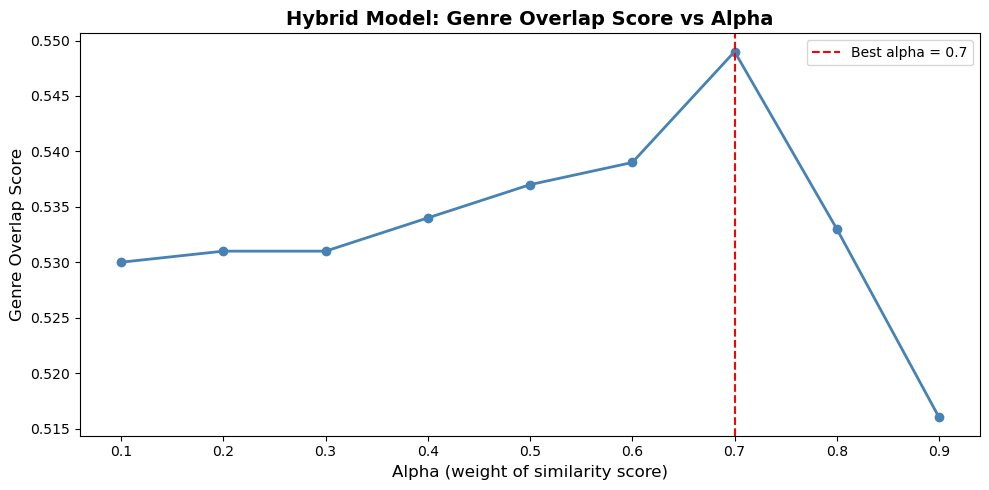

In [34]:
# ── 5. PLOT ALPHA TUNING ──────────────────────────────────────────────────────

plt.figure(figsize=(10, 5))
plt.plot(alphas, alpha_scores, marker="o", color="steelblue", linewidth=2)
plt.axvline(x=best_alpha, color="red", linestyle="--", label=f"Best alpha = {best_alpha}")
plt.title("Hybrid Model: Genre Overlap Score vs Alpha", fontsize=14, fontweight="bold")
plt.xlabel("Alpha (weight of similarity score)", fontsize=12)
plt.ylabel("Genre Overlap Score", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## FINAL COMPARISON TABLE

In [36]:
# ── 6. FINAL COMPARISON TABLE (All 3 Models) ──────────────────────────────────

# Re-evaluate Model 2 and Hybrid with same sample for fair comparison
print("Evaluating Model 2 for final comparison...")
score_m2 = evaluate_genre_overlap(recommend_nn, sample_size=200)

print("Evaluating Model 3 Hybrid (best alpha)...")
score_m3 = evaluate_genre_overlap(
    recommend_hybrid, sample_size=200, alpha=best_alpha
)

comparison = pd.DataFrame({
    "Model": [
        "Model 1 — Popularity (Weighted Rating)",
        "Model 2 — Content-Based (TF-IDF + KNN)",
        "Model 3 — Hybrid (Similarity + Popularity)"
    ],
    "Method": [
        "Weighted rating formula (IMDB-style)",
        "TF-IDF cosine similarity via NearestNeighbors",
        f"α×similarity + (1-α)×popularity  |  best α={best_alpha}"
    ],
    "Personalized": ["No", "Yes", "Yes"],
    "Hyperparameter": [
        "vote quantile threshold (m)",
        "max_features, ngram_range",
        f"alpha={best_alpha} (tuned)"
    ],
    "Genre Overlap Score": [
        "N/A (baseline)",
        f"{score_m2:.4f}",
        f"{score_m3:.4f}"
    ],
    "Best use case": [
        "Cold start / homepage top picks",
        "Find movies similar to a title",
        "Similar + highly rated movies"
    ]
})

display(comparison)

Evaluating Model 2 for final comparison...
Finding recommendations for: 'The Big Hit' (1998)
Query time: 0.386s | Results: 10
Finding recommendations for: 'Shadow of the Eagle' (2005)
Query time: 0.162s | Results: 10
Finding recommendations for: 'Charged: The Eduardo Garcia Story' (2017)
Query time: 0.161s | Results: 10
Finding recommendations for: 'Moro no Brasil' (2002)
Query time: 0.152s | Results: 10
Finding recommendations for: 'Olsen Gang Gets Polished' (2010)
Query time: 0.150s | Results: 10
Finding recommendations for: 'Made in USSR' (1991)
Query time: 0.161s | Results: 10
Finding recommendations for: 'Loving Carolina' (2018)
Query time: 0.168s | Results: 10
Finding recommendations for: 'All About "All About Lily Chou-Chou"' (2002)
Query time: 0.156s | Results: 10
Finding recommendations for: 'Biohazard: The Alien Force' (1994)
Query time: 0.154s | Results: 10
Finding recommendations for: 'Maneater' (2022)
Query time: 0.156s | Results: 10
Finding recommendations for: 'Yehoshua 

,Model,Method,Personalized,Hyperparameter,Genre Overlap Score,Best use case
0,Model 1 — Popularity (Weighted Rating),Weighted rating formula (IMDB-style),No,vote quantile threshold (m),N/A (baseline),Cold start / homepage top picks
1,Model 2 — Content-Based (TF-IDF + KNN),TF-IDF cosine similarity via NearestNeighbors,Yes,"max_features, ngram_range",0.5005,Find movies similar to a title
2,Model 3 — Hybrid (Similarity + Popularity),α×similarity + (1-α)×popularity | best α=0.7,Yes,alpha=0.7 (tuned),0.5635,Similar + highly rated movies


In [38]:
# ── ERROR ANALYSIS ────────────────────────────────────────────────────────────

print("=== KNOWN LIMITATIONS ===\n")

# 1. Movies not found (no title match)
not_found = [t for t in df["title"] if get_movie_idx(t) is None]
print(f"1. Movies with no title match: {len(not_found)}")

# 2. Movies with empty tags (no content to compare)
empty_tags = df[df["tags"].str.strip() == ""]
print(f"2. Movies with empty tags: {len(empty_tags)}")

# 3. Movies with very low vote count (unreliable ratings)
low_votes = df[df["vote_count"] < 10]
print(f"3. Movies with fewer than 10 votes: {len(low_votes)}")

# 4. Show example of a bad recommendation (low similarity scores)
print("\n=== EXAMPLE: Low confidence recommendations ===")
bad_example = recommend_hybrid("Cosmographies", n=5, alpha=0.7)
display(bad_example)
print("Note: Obscure/niche movies with sparse tags get lower quality recommendations.")

=== KNOWN LIMITATIONS ===

1. Movies with no title match: 0
2. Movies with empty tags: 0
3. Movies with fewer than 10 votes: 324260

=== EXAMPLE: Low confidence recommendations ===
Finding hybrid recommendations for: 'Cosmographies' (2024) | alpha=0.7
Query time: 0.526s | Results: 5


,title,release_year,genres,vote_average,vote_count,similarity_score,popularity_score,hybrid_score
1,Expedition Mars: Spirit & Opportunity,2016,Documentary,8.2,13,0.1529,0.5625,0.2758
58,Life,2017,"Horror, Science Fiction, Mystery",6.5,7871,0.1019,0.6064,0.2533
37,Brian Cox: Seven Days on Mars,2022,Documentary,7.5,13,0.1104,0.5111,0.2306
2,The Hunt For Planet B,2021,Documentary,7.2,6,0.1482,0.3949,0.2222
63,Project Gemini,2022,"Science Fiction, Thriller",5.7,487,0.1009,0.5033,0.2216


Note: Obscure/niche movies with sparse tags get lower quality recommendations.
